In [7]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.io import decode_image
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)])
)

In [3]:
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)])
)

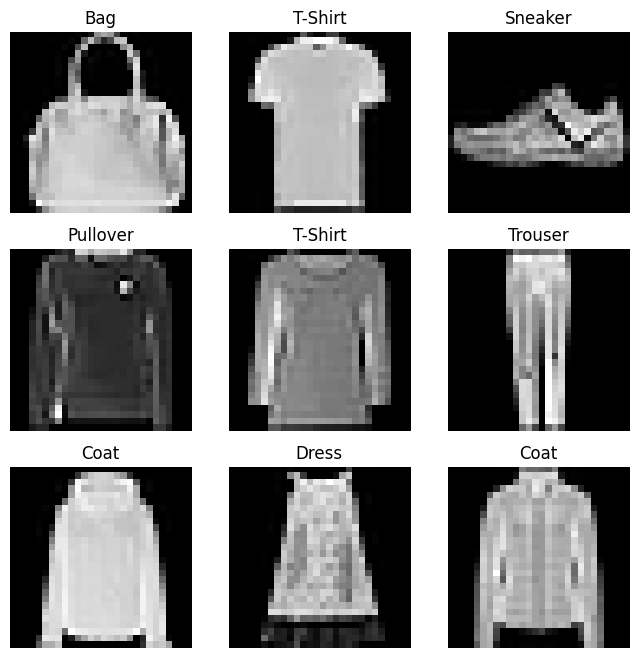

In [4]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8,8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size = (1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap = "grey")
plt.show()

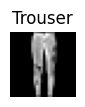

In [5]:
image, label = train_data[78]
fig = plt.figure(figsize = (10, 10))
fig.add_subplot(10, 3, 5)
plt.title(labels_map[label])
plt.axis("off")
plt.imshow(image.squeeze(), cmap = "grey")
plt.show()

In [8]:
#custom dataset architecture

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform = None, target_transform = None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        img = decode_image(img_path)
        label = self.img_labels.iloc[idx, 0]
        img = img if not self.transform else self.transform(img)
        label = label if not self.target_transform else self.target_transform(label)
        return image, label

In [9]:
# dataloaders

from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size = 32, shuffle = True) 
test_dataloader = DataLoader(test_data, batch_size = 32, shuffle = True) 

Feature batch shape: torch.Size([32, 1, 28, 28])
Target batch shape: torch.Size([32])


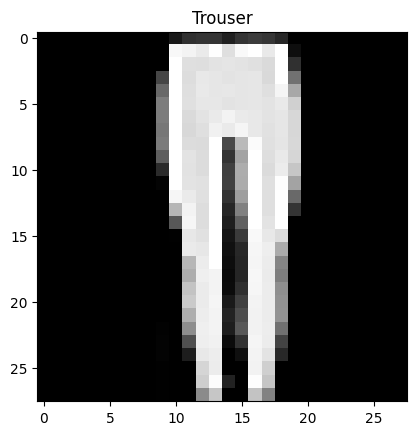

In [11]:
# display image and label

train_features, train_labels = next(iter(train_dataloader))

print(f"Feature batch shape: {train_features.size()}\n"
      f"Target batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
label = train_labels[0].item()
plt.imshow(img, cmap = "grey")
plt.title(labels_map[label])
plt.show()